# Лабораторная работа 1

In [164]:
import numpy
from matplotlib import pyplot
from scipy import stats

## Задача 1

Для равномерного $\mathcal{R}[-2, 1]$, нормального $\mathcal{N(1,4)}$, показательного $E(3)$ и биномиального $B(10,0.2)$ распределений.

1. Постройте 3 реализации выборки объёмом 10 и в одной системе координат постройте графики трех соответствующих реализаций эмпирической функции распределении.

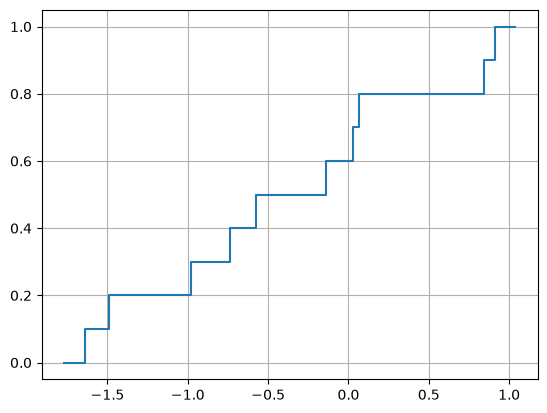

In [165]:
sample = stats.uniform.rvs(-2, 3, size=10)
stats.ecdf(sample).cdf.plot(pyplot)
pyplot.grid()

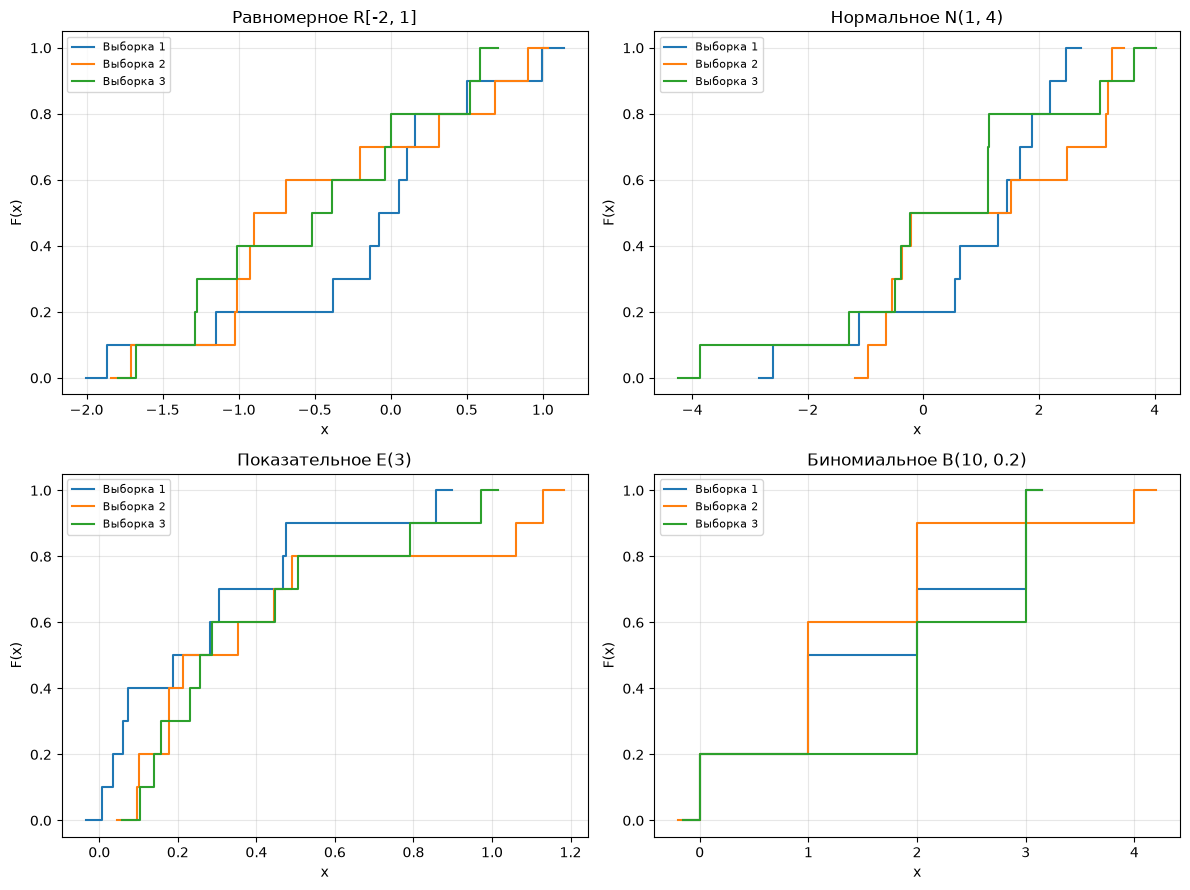

In [166]:
fig, axes = pyplot.subplots(2, 2, figsize=(12, 9))

# Словарь распределений: (название, функция генерации выборки)
distributions = [
    ('Равномерное R[-2, 1]',
     lambda: stats.uniform.rvs(-2, 3, size=10)),
    ('Нормальное N(1, 4)',
     lambda: stats.norm.rvs(1, 2, size=10)),
    ('Показательное E(3)',
     lambda: stats.expon.rvs(scale=1/3, size=10)),
    ('Биномиальное B(10, 0.2)',
     lambda: stats.binom.rvs(10, 0.2, size=10)),
]

# Проходим по всем 4 распределениям и осям
for ax, (name, sampler) in zip(axes.flat, distributions):
    # Строим 3 реализации ЭФР на одной оси
    for i in range(3):
        sample = sampler()
        stats.ecdf(sample).cdf.plot(ax, label=f'Выборка {i+1}')
    
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('F(x)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

2. Постройте реализации выборок объемами 10, 100 и 1000 и в одной системе координат постройте графики реализаций эмпирической функции распределения.

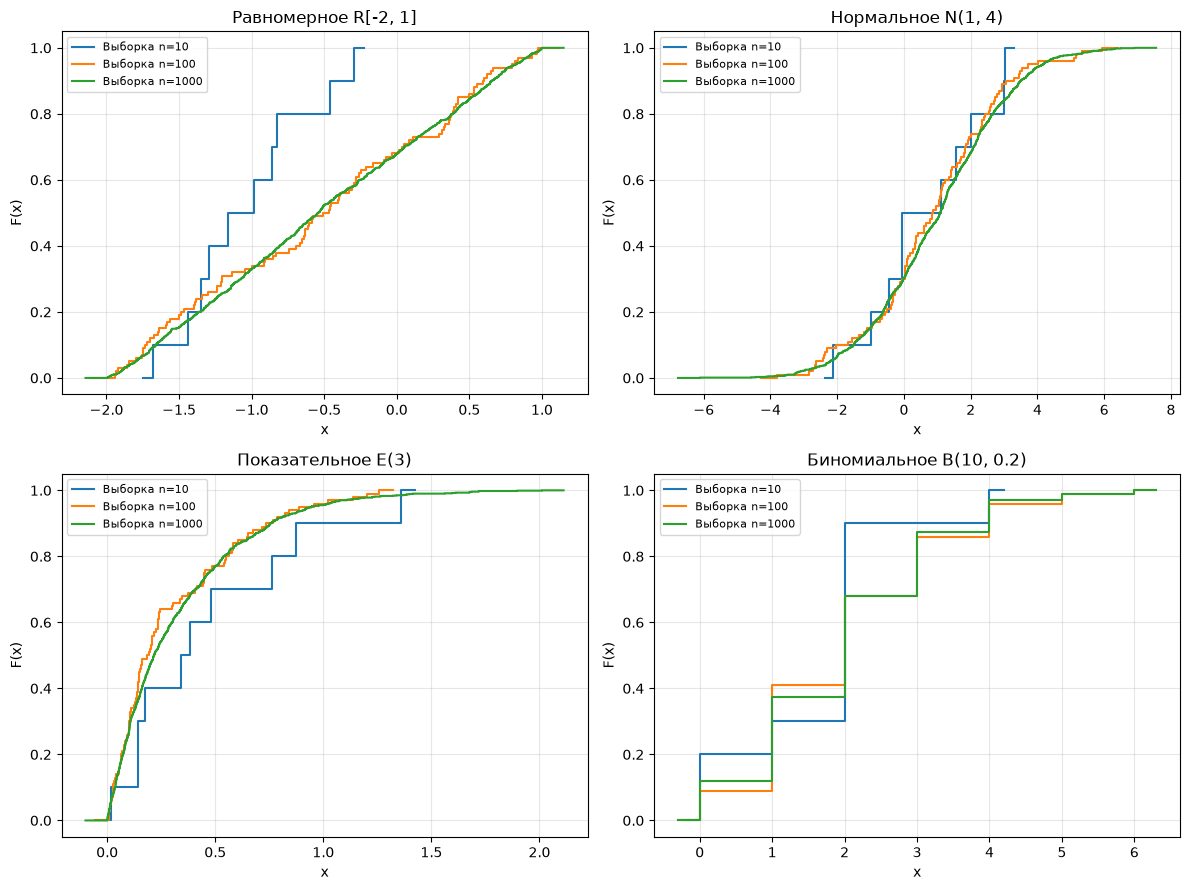

In [167]:
fig, axes = pyplot.subplots(2, 2, figsize=(12, 9))

# Словарь распределений: (название, функция генерации выборки)
distributions = [
    ('Равномерное R[-2, 1]',
     lambda n: stats.uniform.rvs(-2, 3, size=n)),
    ('Нормальное N(1, 4)',
     lambda n: stats.norm.rvs(1, 2, size=n)),
    ('Показательное E(3)',
     lambda n: stats.expon.rvs(scale=1/3, size=n)),
    ('Биномиальное B(10, 0.2)',
     lambda n: stats.binom.rvs(10, 0.2, size=n)),
]

# Проходим по всем 4 распределениям и осям
for ax, (name, sampler) in zip(axes.flat, distributions):
    # Строим 3 реализации ЭФР на одной оси
    for i in range(3):
        sample = sampler(10**(i+1))
        stats.ecdf(sample).cdf.plot(ax, label=f'Выборка n={10**(i+1)}')
    
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('F(x)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

3. Постройте гистограмму для одной реализации выборки объёмом 100.

(array([0.08, 0.13, 0.1 , 0.13, 0.13, 0.09, 0.14, 0.14, 0.06]),
 array([-2.        , -1.66666667, -1.33333333, -1.        , -0.66666667,
        -0.33333333,  0.        ,  0.33333333,  0.66666667,  1.        ]),
 <BarContainer object of 9 artists>)

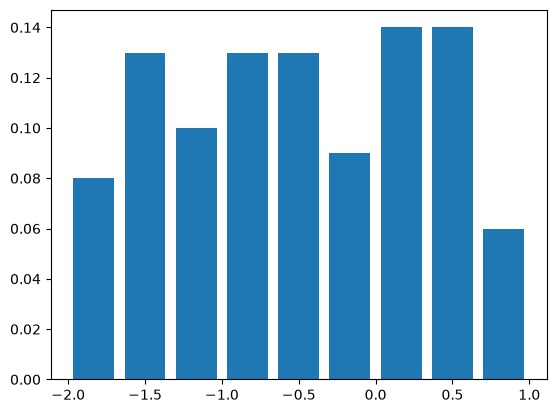

In [168]:
sample = stats.uniform.rvs(-2, 3, size=100)
bins = numpy.linspace(-2, 1, 10)
counts, _ = numpy.histogram(sample, bins=bins)
counts = counts / sample.size
pyplot.hist(bins[:-1], bins, weights=counts, rwidth=0.8)

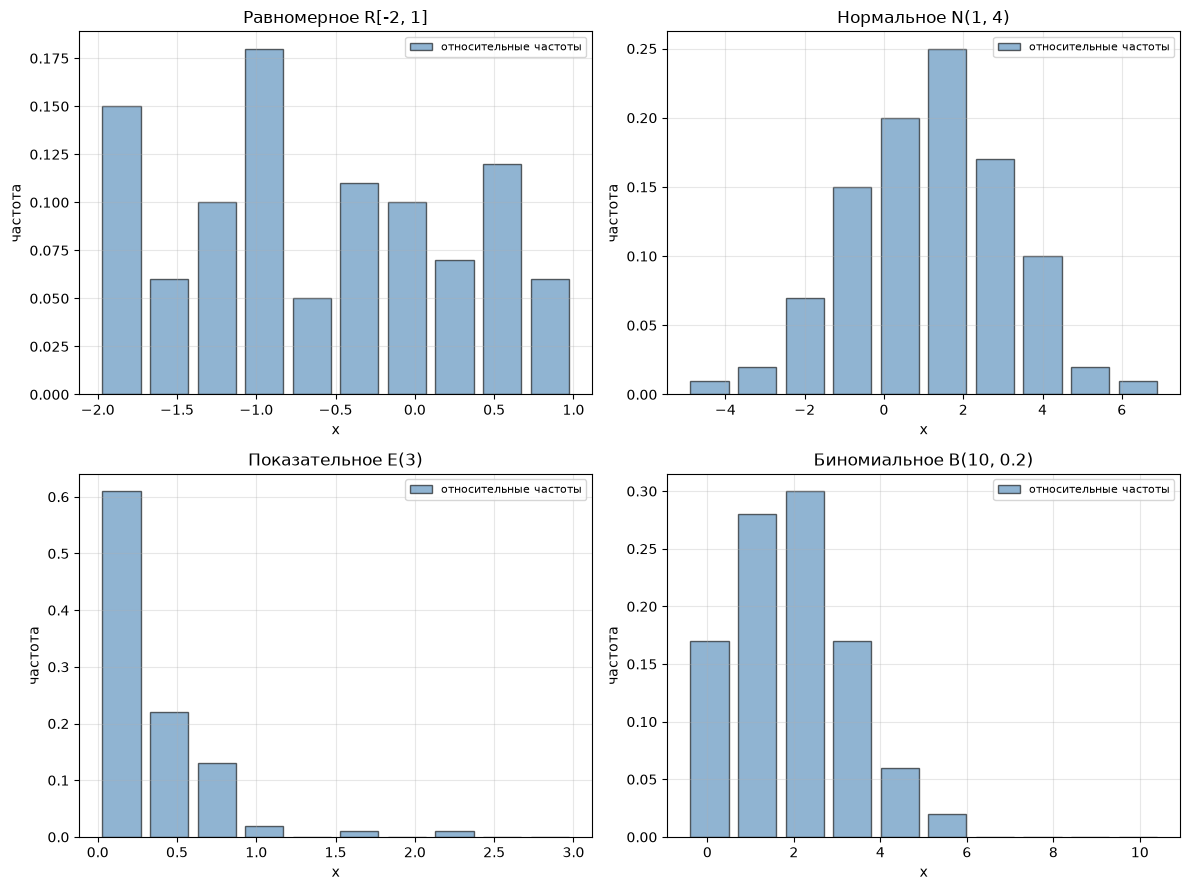

In [169]:
fig, axes = pyplot.subplots(2, 2, figsize=(12, 9))

distributions = [
    ('Равномерное R[-2, 1]',
     lambda n: stats.uniform.rvs(-2, 3, size=n),
     stats.uniform(-2, 3), (-2, 1)),
    ('Нормальное N(1, 4)',
     lambda n: stats.norm.rvs(1, 2, size=n),
     stats.norm(1, 2), (-5, 7)),
    ('Показательное E(3)',
     lambda n: stats.expon.rvs(scale=1/3, size=n),
     stats.expon(scale=1/3), (0, 3)),
    ('Биномиальное B(10, 0.2)',
     lambda n: stats.binom.rvs(10, 0.2, size=n),
     stats.binom(10, 0.2), (-0.5, 10.5)),
]

n = 100
nbins = 10

for ax, (name, sampler, theo, xlim) in zip(axes.flat, distributions):
    sample = sampler(n)
    bins = numpy.linspace(*xlim, nbins + 1)
    
    # Вариант A: гистограмма относительных частот (как у вас)
    counts, _ = numpy.histogram(sample, bins=bins)
    freq = counts / sample.size
    ax.hist(bins[:-1], bins, weights=freq, rwidth=0.8,
            color='steelblue', edgecolor='black', alpha=0.6,
            label='относительные частоты')
    
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('частота')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

4. По одной реализации выборки объемом 100 вычислите реализации выборочного среднего, выборочной дисперсии, выборочного начального момента 2-го порядка. Сравните вычисленные величины с точными значениями математического ожидания, дисперсии и второго начального момента 2-го порядка.

In [170]:
a, b = -2, 1
sample = stats.uniform.rvs(a, b-a, size=100)
m_1 = stats.moment(sample, order=1, center=0)
mu_2 = stats.moment(sample, order=2, center=numpy.mean(sample))
m_2 = stats.moment(sample, order=2, center=0)
print(f'{"1ый начальный":20}{m_1:.3f} - {(a+b)/2:.3f}')
print(f'{"2ой центральный":20}{mu_2:.3f} - {(b-a)**2/12:.3f}')
print(f'{"2ой начальный":20}{m_2:.3f} - {(b**3-a**3)/(3*(b-a)):.3f}')

1ый начальный       -0.433 - -0.500
2ой центральный     0.846 - 0.750
2ой начальный       1.033 - 1.000


In [171]:
n = 100

distributions = [
    ('Равномерное R[-2, 1]',
     lambda: stats.uniform.rvs(-2, 3, size=n),
     1/2 * (-2 + 1),           # M[X]
     (1 - (-2))**2 / 12,       # D[X]
     (1**3 - (-2)**3) / (3 * (1 - (-2)))),  # M[X^2]

    ('Нормальное N(1, 4)',
     lambda: stats.norm.rvs(1, 2, size=n),
     1,                        # M[X]
     4,                        # D[X]
     4 + 1**2),                # M[X^2]

    ('Показательное E(3)',
     lambda: stats.expon.rvs(scale=1/3, size=n),
     1/3,                      # M[X]
     1/9,                      # D[X]
     2/9),                     # M[X^2]

    ('Биномиальное B(10, 0.2)',
     lambda: stats.binom.rvs(10, 0.2, size=n),
     10 * 0.2,                 # M[X]
     10 * 0.2 * 0.8,           # D[X]
     10 * 0.2 * 0.8 + (10 * 0.2)**2),  # M[X^2]
]

for name, sampler, theo_mean, theo_var, theo_m2 in distributions:
    sample = sampler()
    
    # Выборочные характеристики
    m_1 = stats.moment(sample, order=1, center=0)                 # выборочное среднее
    mu_2 = stats.moment(sample, order=2, center=numpy.mean(sample))                # выборочная дисперсия 
    m_2 = stats.moment(sample, order=2, center=0)            # выборочный начальный момент 2-го порядка
    
    print(f'\n=== {name} ===')
    print(f'{"1ый начальный":25}{m_1:8.4f}  -  {theo_mean:8.4f}')
    print(f'{"2ой центральный":25}{mu_2:8.4f}  -  {theo_var:8.4f}')
    print(f'{"2ой начальный":25}{m_2:8.4f}  -  {theo_m2:8.4f}')
    
    # # Проверка: m_2 = mu_2 + m_1^2
    # print(f'{mu_2 + m_1**2=:.4f} == {m_2:.4f}')


=== Равномерное R[-2, 1] ===
1ый начальный             -0.5609  -   -0.5000
2ой центральный            0.7195  -    0.7500
2ой начальный              1.0342  -    1.0000

=== Нормальное N(1, 4) ===
1ый начальный              1.1418  -    1.0000
2ой центральный            4.3759  -    4.0000
2ой начальный              5.6797  -    5.0000

=== Показательное E(3) ===
1ый начальный              0.3271  -    0.3333
2ой центральный            0.0923  -    0.1111
2ой начальный              0.1992  -    0.2222

=== Биномиальное B(10, 0.2) ===
1ый начальный              1.9500  -    2.0000
2ой центральный            1.3675  -    1.6000
2ой начальный              5.1700  -    5.6000


## Задача 2

По выборке $(\xi_1, \dots, \xi_n)$ из биномиального распределения Бернулли $Be(p)$ вычисляется оценка вероятности:
$$
    \widehat{p} = \frac{1}{n} \sum \limits_{i=1}^n \xi_i.
$$

Выберите произвольным образом значение вероятности $p$.

Постройте 20 реализаций выборки объемами $𝑛_1 = 10$ и $𝑛_2 = 50$, для всех реализаций вычислите оценку $\widehat{p}$.

В одной системе координат на двух прямых, параллельных оси абсцисс и пересекающие ось ординат в точках $(0, 𝑛_1)$ и $(0, 𝑛_2)$, отметьте точками (маркерами) все полученные значения оценки для объема выборки $𝑛_1$ и для объема выборки $𝑛_2$ соответственно. В этой же системе координат проведите три прямые параллельные оси ординат и пересекающие ось абсцисс в точках,
соответствующих двум средним арифметическим значений оценки $\widehat{p}$ для объемов $𝑛_1$ и $𝑛_2$, а также точному значению параметра $p$.

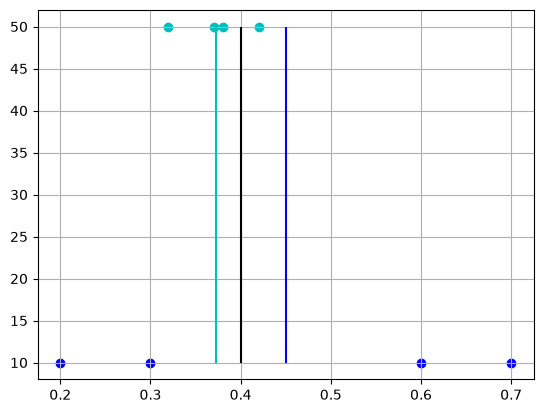

In [172]:
p = 0.4
n_1, n_2 = 10, 50
p_1 = numpy.array([0.7, 0.2, 0.3, 0.6])
p_2 = numpy.array([0.37, 0.42, 0.32, 0.38])

pyplot.scatter(p_1, [n_1]*len(p_1), color='b')
pyplot.scatter(p_2, [n_2]*len(p_2), color='c')
pyplot.vlines([p_1.mean(), p_2.mean(), p], n_1, n_2, colors=['b', 'c', 'k'])
pyplot.grid()

Среднее p_hat при n=10:  0.1800
Среднее p_hat при n=50:  0.2030
Точное значение p:          0.2000


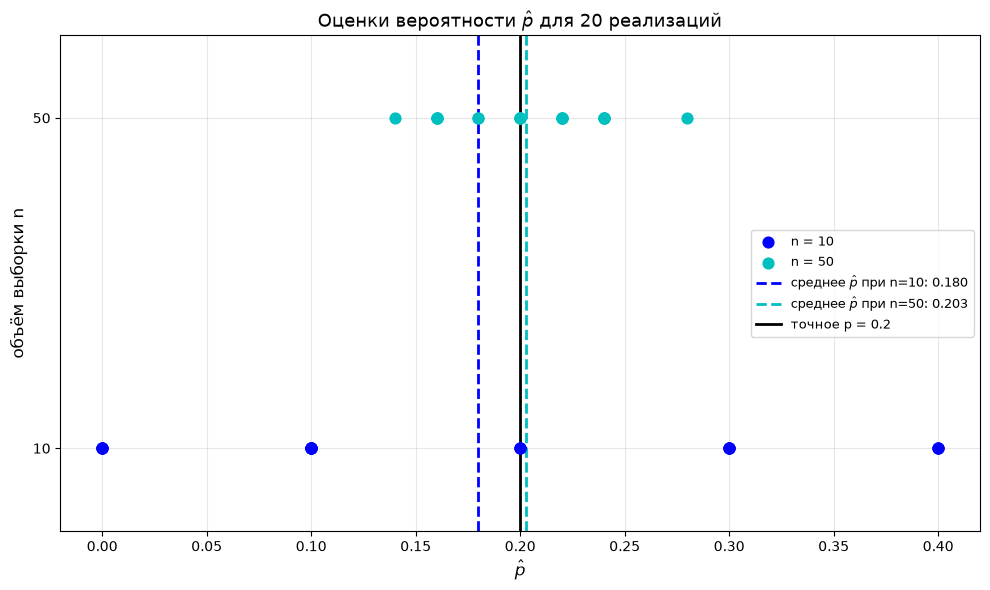

In [173]:
# Параметры задачи
p = 0.2
n_1, n_2 = 10, 50
N = 20          # количество реализаций

# 20 реализаций выборок и оценки p_hat для каждого объёма
p_hat_1 = numpy.array([stats.bernoulli.rvs(p, size=n_1).mean() for _ in range(N)])
p_hat_2 = numpy.array([stats.bernoulli.rvs(p, size=n_2).mean() for _ in range(N)])

# Средние арифметические оценок
mean_1 = p_hat_1.mean()
mean_2 = p_hat_2.mean()

print(f'Среднее p_hat при n={n_1}:  {mean_1:.4f}')
print(f'Среднее p_hat при n={n_2}:  {mean_2:.4f}')
print(f'Точное значение p:          {p:.4f}')

# График
fig, ax = pyplot.subplots(figsize=(10, 6))

# Точки: оценка p_hat для каждой реализации
ax.scatter(p_hat_1, [n_1] * N, color='b', s=60, zorder=3,
           label=f'n = {n_1}')
ax.scatter(p_hat_2, [n_2] * N, color='c', s=60, zorder=3,
           label=f'n = {n_2}')

# Три вертикальные прямые на всю высоту графика
ax.axvline(mean_1, color='b', linestyle='--', linewidth=2,
           label=f'среднее $\\hat{{p}}$ при n={n_1}: {mean_1:.3f}')
ax.axvline(mean_2, color='c', linestyle='--', linewidth=2,
           label=f'среднее $\\hat{{p}}$ при n={n_2}: {mean_2:.3f}')
ax.axvline(p, color='k', linestyle='-', linewidth=2,
           label=f'точное p = {p}')

ax.set_xlabel('$\\hat{p}$', fontsize=12)
ax.set_ylabel('объём выборки n', fontsize=12)
ax.set_title('Оценки вероятности $\\hat{p}$ для 20 реализаций', fontsize=13)
ax.set_yticks([n_1, n_2])
ax.set_ylim(0, n_2 + 10)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='center right')

pyplot.tight_layout()
pyplot.show()

## Задача 3

По выборке $(\xi_1, \dots, \xi_n)$ из показательного распределения $E(\lambda)$ вычисляются оценки параметра $\lambda$:
$$
    \overline{\lambda}_k(\zeta_n) = \sqrt[k]{\frac{k!}{\widehat{m}_k(\zeta_n)}} , \\
    \widehat{m}_k(\zeta_n) = \frac{1}{n} \sum_{i=1}^n \xi_i^k,
$$

Постройте 50 реализаций объёма $n=100$. Для каждого $k$ от 1 до 20 вычислите 50 значений оценки $\widehat{\lambda}_k$, используя построенные реализации, вычислите среднеквадратические отклонения значений оценки $\sigma_k$ и постройте график значений $\sigma_k$ в зависимости от $k$.

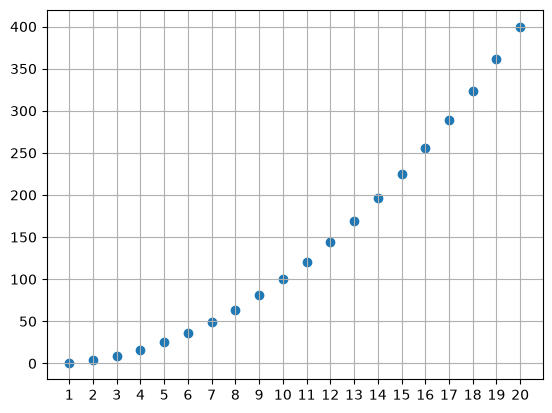

In [174]:
k = numpy.array(range(1,21))
s = k**2
pyplot.scatter(k, s)
pyplot.xticks(range(1,21))
pyplot.grid()

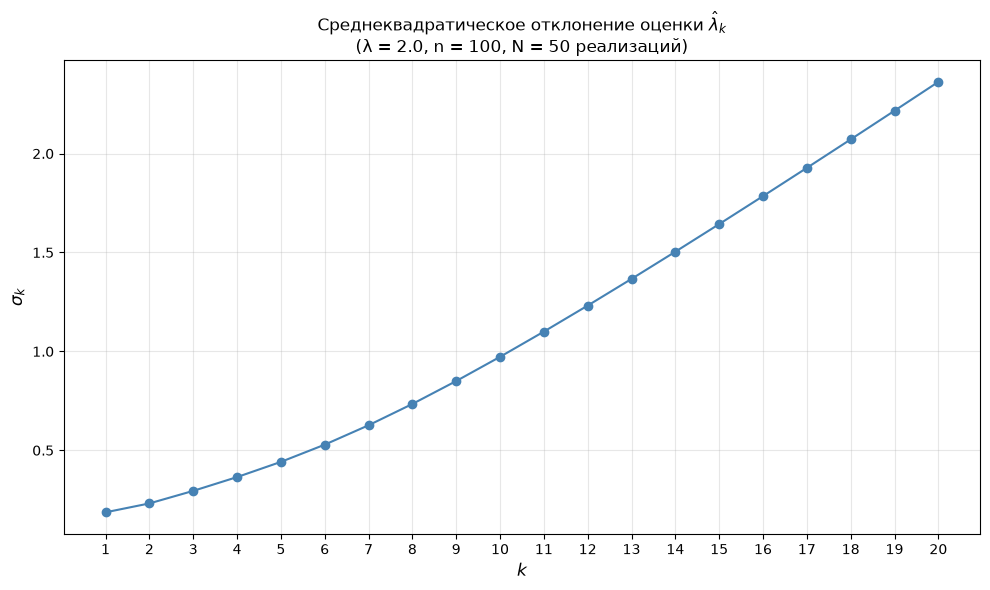

In [175]:
from math import factorial

# Параметры задачи
lam = 2.0          # истинное значение λ (выбираем произвольно)
n = 100            # объём выборки
N = 50             # количество реализаций
k_max = 20         # максимальный порядок момента

# Генерируем 50 реализаций выборки объёма n
samples = stats.expon.rvs(scale=1/lam, size=(N, n))

# Массив для среднеквадратических отклонений σ_k
sigma_k = numpy.zeros(k_max)

for k in range(1, k_max + 1):
    # Для каждой из 50 реализаций считаем m_hat_k и lambda_hat_k
    m_hat = numpy.mean(samples**k, axis=1)              # shape (N,)
    lambda_hat = (factorial(k) / m_hat) ** (1 / k)      # shape (N,)
    
    # Среднеквадратическое отклонение 50 значений оценки
    # (относительно истинного λ или относительно их среднего — см. ниже)
    sigma_k[k - 1] = numpy.sqrt(numpy.mean((lambda_hat - lam) ** 2))

# График
fig, ax = pyplot.subplots(figsize=(10, 6))
ax.plot(range(1, k_max + 1), sigma_k, 'o-',
        color='steelblue', linewidth=1.5, markersize=6)
ax.set_xlabel('$k$', fontsize=12)
ax.set_ylabel('$\\sigma_k$', fontsize=12)
ax.set_title(f'Среднеквадратическое отклонение оценки $\\hat{{\\lambda}}_k$\n'
             f'(λ = {lam}, n = {n}, N = {N} реализаций)', fontsize=12)
ax.set_xticks(range(1, k_max + 1))
ax.grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

## Задача 4

По выборке $(\xi_1, \dots, \xi_n)$ из равномерного распределения $𝑅[a, b]$ построены три оценки двумерного параметра $(a,b)$.

Методом моментов:
$$
    \overline{a} = \widehat{m}_1 - \sqrt{3 \widehat{\mu}_2}, \\
    \overline{b} = \widehat{m}_1 + \sqrt{3 \widehat{\mu}_2} .
$$

Методом порядковых статистик:
$$
    \widetilde{a} = \frac{p_2 \widetilde{x}_{p_1} - p_1 \widetilde{x}_{p_2}}{p_2 - p_1}, \\
    \widetilde{b} = \frac{(1-p_2) \widetilde{x}_{p_1} - (1 - p_1) \widetilde{x}_{p_2}}{p_1 - p_2} ,
$$
где $p_1$ и $p_2$ --- уровни квантилей (можно выбрать произвольным образом), а $\widetilde{x}_{p_1}$ и $\widetilde{x}_{p_2}$ --- выборочные квантили уровней $p_1$ и $p_2$ --- порядковые статистики $\xi_{(np_1+1)}$ и $\xi_{(np_2+1)}$.

Методом максимального правдоподобия:
$$
    \widehat{a} = \xi_{(1)}, \\
    \widehat{b} = \xi_{(n)} .
$$

Выберите произвольным образом значения $a$ и $b$.

Постройте по 20 реализаций выборок объемов $n_1 = 10$, $n_2 = 50$ и $n_3 = 100$ и для всех реализаций выборок вычислите соответствующие значения всех трех оценок.

Для каждого объема выборки в отдельной системе координат изобразите вычисленные значения трех оценок в виде маркеров, расположенных на трех разных прямых параллельных оси абсцисс (поскольку каждая оценка является двумерной статистикой, то на одной и той же прямой располагаются и значения оценки $a$ и значения оценки для компоненты $b$). В каждой системе координат проведите две прямые параллельные оси ординат и пересекающие ось абсцисс в точках $a$ и $b$. Все три системы координат должны иметь одинаковый масштаб.

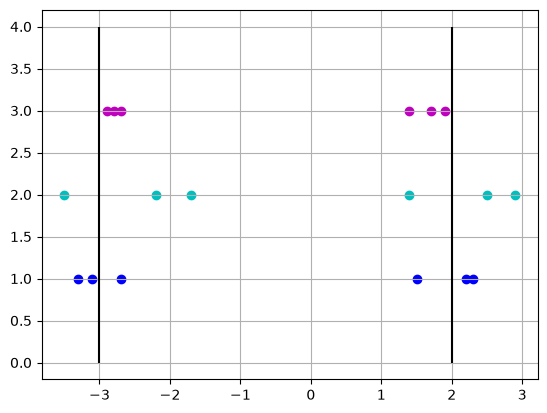

In [176]:
a, b = -3, 2
a_m = [-2.7, -3.3, -3.1]
b_m = [2.2, 1.5, 2.3]
a_q = [-3.5, -1.7, -2.2]
b_q = [1.4, 2.9, 2.5]
a_l = [-2.8, -2.9, -2.7]
b_l = [1.4, 1.9, 1.7]
pyplot.scatter(a_m, [1]*len(a_m), color='b')
pyplot.scatter(b_m, [1]*len(b_m), color='b')
pyplot.scatter(a_q, [2]*len(a_q), color='c')
pyplot.scatter(b_q, [2]*len(b_q), color='c')
pyplot.scatter(a_l, [3]*len(a_l), color='m')
pyplot.scatter(b_l, [3]*len(b_l), color='m')
pyplot.vlines([a, b], 0, 4, colors=['k', 'k'])
pyplot.grid()

In [177]:
# Истинные параметры
a, b = -3.0, 2.0

# Объёмы выборок и число реализаций
sizes = [10, 50, 100]
N = 20

# Уровни квантилей для метода порядковых статистик
p1, p2 = 0.25, 0.75


def estimates_moments(sample):
    """Метод моментов."""
    m1 = numpy.mean(sample)
    mu2 = numpy.var(sample)                  # центральный момент 2-го порядка
    a_hat = m1 - numpy.sqrt(3 * mu2)
    b_hat = m1 + numpy.sqrt(3 * mu2)
    return a_hat, b_hat


def estimates_quantiles(sample, p1=0.25, p2=0.75):
    """Метод порядковых статистик."""
    n = len(sample)
    x_sorted = numpy.sort(sample)
    # порядковые статистики x_(n*p+1); индексация с 0 → минус 1
    i1 = int(n * p1 + 1) - 1
    i2 = int(n * p2 + 1) - 1
    i1 = min(max(i1, 0), n - 1)              # защита от выхода за границы
    i2 = min(max(i2, 0), n - 1)
    x_p1 = x_sorted[i1]
    x_p2 = x_sorted[i2]
    
    a_hat = (p2 * x_p1 - p1 * x_p2) / (p2 - p1)
    b_hat = ((1 - p2) * x_p1 - (1 - p1) * x_p2) / (p1 - p2)
    return a_hat, b_hat


def estimates_mle(sample):
    """Метод максимального правдоподобия."""
    return numpy.min(sample), numpy.max(sample)


# Словарь оценок: название → функция
estimators = {
    'moments':   estimates_moments,
    'quantiles': estimates_quantiles,
    'mle':       estimates_mle,
}

# Структура для хранения результатов:
# results[n][method] = (массив a_hat, массив b_hat)
results = {n: {m: (numpy.zeros(N), numpy.zeros(N)) for m in estimators}
           for n in sizes}

for n in sizes:
    for j in range(N):
        sample = stats.uniform.rvs(a, b - a, size=n)
        for name, func in estimators.items():
            a_hat, b_hat = func(sample)
            results[n][name][0][j] = a_hat
            results[n][name][1][j] = b_hat

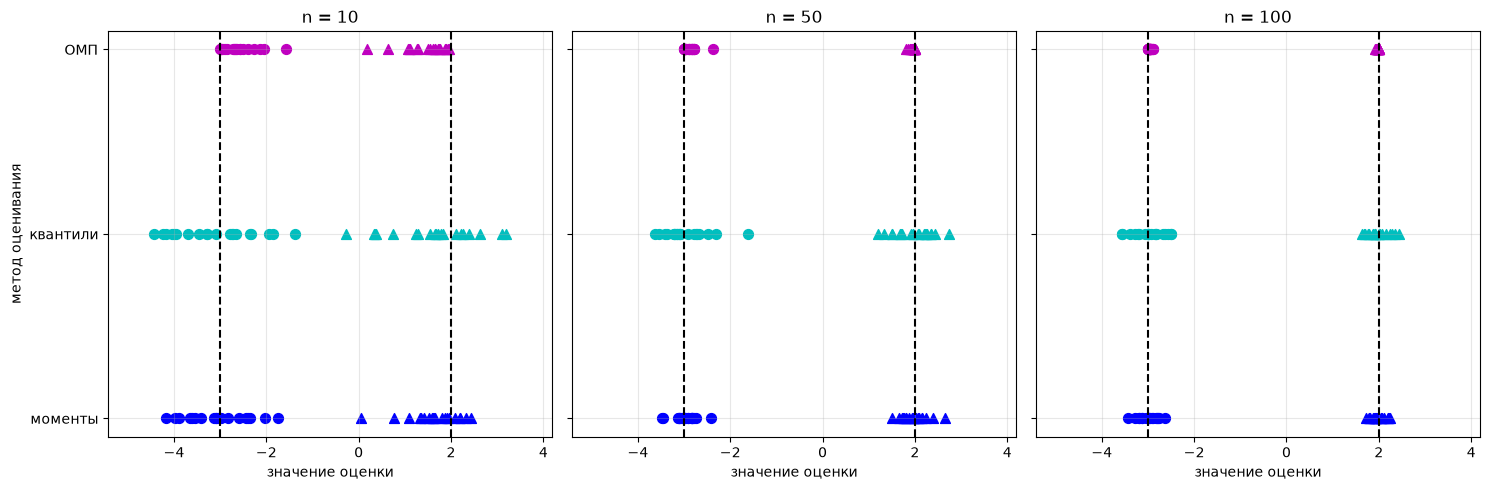

In [178]:
fig, axes = pyplot.subplots(1, 3, figsize=(15, 5), sharey=True)

colors = {'moments': 'b', 'quantiles': 'c', 'mle': 'm'}
labels = {'moments': 'метод моментов',
          'quantiles': 'порядковые статистики',
          'mle': 'максимальное правдоподобие'}

# Единый масштаб по оси X для всех трёх графиков
x_min = min(a, min(results[n][m][0].min() for n in sizes for m in estimators)) - 1
x_max = max(b, max(results[n][m][1].max() for n in sizes for m in estimators)) + 1

for ax, n in zip(axes, sizes):
    for i, (name, _) in enumerate(estimators.items()):
        a_vals, b_vals = results[n][name]
        # Оценки a и b — на одной прямой y = i
        ax.scatter(a_vals, [i] * N, color=colors[name], s=50,
                   label=f'{labels[name]}: $\\bar{{a}}$' if i == 0 else None)
        ax.scatter(b_vals, [i] * N, color=colors[name], s=50, marker='^')
    
    # Вертикальные прямые через истинные a и b
    ax.axvline(a, color='k', linewidth=1.5, linestyle='--')
    ax.axvline(b, color='k', linewidth=1.5, linestyle='--')
    
    ax.set_title(f'n = {n}', fontsize=12)
    ax.set_xlabel('значение оценки')
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['моменты', 'квантили', 'ОМП'])
    ax.set_xlim(x_min, x_max)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('метод оценивания')
pyplot.tight_layout()
pyplot.show()

Для каждого объема выборки и каждой оценки вычислите среднеквадратическое отклонение полученных значений оценок. Постройте в одной системе координат три ломанных, каждая из которых отражает зависимость среднеквадратических отклонений оценок от объема выборки $n$, откладывая значения среднеквадратических отклонений по оси ординат и объемы выборок по оси абсцисс. На основе построенных ломаных укажите, какая оценка из трех построенных кажется наилучшей.

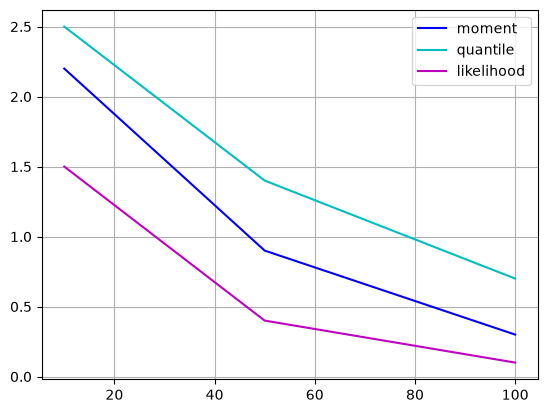

In [179]:
s_m = [2.2, 0.9, 0.3]
s_q = [2.5, 1.4, 0.7]
s_l = [1.5, 0.4, 0.1]
n = [10, 50, 100]
pyplot.plot(n, s_m, color='b', label='moment')
pyplot.plot(n, s_q, color='c', label='quantile')
pyplot.plot(n, s_l, color='m', label='likelihood')
pyplot.legend()
pyplot.grid()

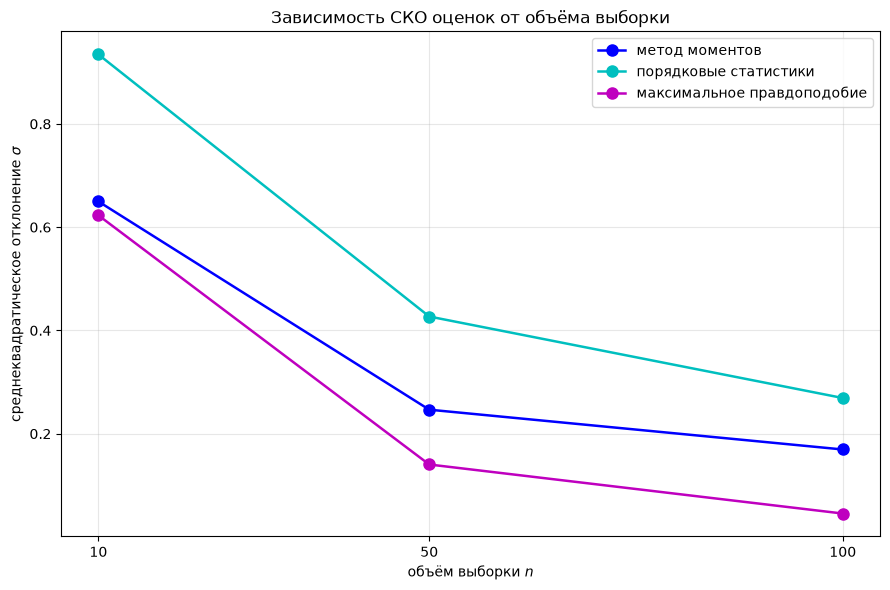

    n метод                         σ
   10 метод моментов           0.6498
   10 порядковые статистики    0.9345
   10 максимальное правдоподобие   0.6229

   50 метод моментов           0.2465
   50 порядковые статистики    0.4269
   50 максимальное правдоподобие   0.1403

  100 метод моментов           0.1694
  100 порядковые статистики    0.2691
  100 максимальное правдоподобие   0.0453



In [180]:
# σ для каждой оценки: считаем по каждой компоненте и усредняем (или берём суммарное)
sigma = {name: numpy.zeros(len(sizes)) for name in estimators}

for i, n in enumerate(sizes):
    for name in estimators:
        a_vals, b_vals = results[n][name]
        # СКО относительно истинного значения, объединяя a и b:
        err_a = (a_vals - a) ** 2
        err_b = (b_vals - b) ** 2
        sigma[name][i] = numpy.sqrt((err_a.mean() + err_b.mean()) / 2)

fig, ax = pyplot.subplots(figsize=(9, 6))
for name in estimators:
    ax.plot(sizes, sigma[name], 'o-', color=colors[name],
            label=labels[name], linewidth=1.8, markersize=8)

ax.set_xlabel('объём выборки $n$')
ax.set_ylabel('среднеквадратическое отклонение $\\sigma$')
ax.set_title('Зависимость СКО оценок от объёма выборки')
ax.set_xticks(sizes)
ax.legend()
ax.grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

# Вывод числовых результатов
print(f'{"n":>5} {"метод":<22} {"σ":>8}')
for i, n in enumerate(sizes):
    for name in estimators:
        print(f'{n:>5} {labels[name]:<22} {sigma[name][i]:>8.4f}')
    print()